In [1]:
import datetime
import warnings

import matplotlib.font_manager as font_manager
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os, sys
sys.path.append(os.path.abspath('/Users/julius/git/tabularml'))
from data import load_data


In [13]:

np.random.seed(42)

path = '/Users/julius/git/algo_trade/data/earn_pg_train_and_val_all_to_20240723_cleaned.csv'
path = '/Users/julius/git/algo_trade/data/earn_pg_train_and_val_all_to_20240723.csv'
target = "r_posn"
target = "r_rnet"

df = load_data(
    path,
)


2024-08-05 18:56:10,982 - INFO - Loading data from /Users/julius/git/algo_trade/data/earn_pg_train_and_val_all_to_20240723.csv
2024-08-05 18:56:11,029 - INFO - Raw data shape: (12409, 73)


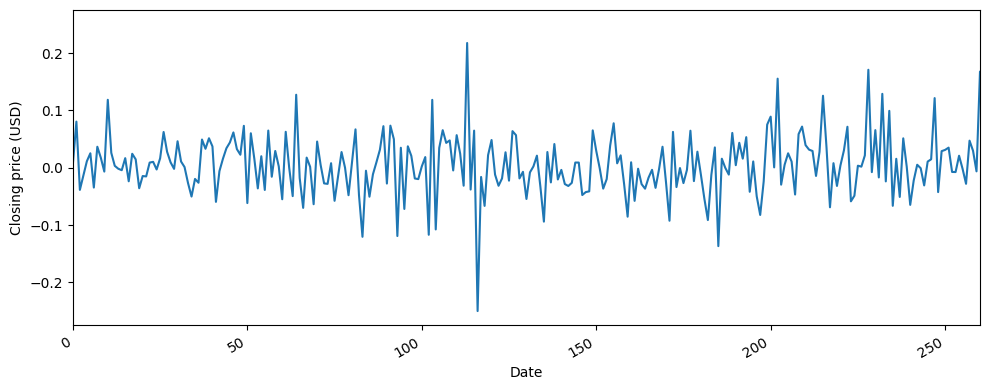

In [14]:
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(df[target])
ax.set_xlabel('Date')
ax.set_ylabel('Closing price (USD)')

ax.set_xlim(0, 260)

fig.autofmt_xdate()
plt.tight_layout()

In [15]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
ID,12409.0,5185227.947538,138872.0,147427.0,156596.0,10783505.0,10794180.0,5310662.728434
m_mopg,12409.0,0.001807,-0.01684,-0.00147,0.00132,0.00465,0.02,0.005528
m_peops,12409.0,0.181745,-0.35,0.0,0.2,0.37999,0.6,0.221452
m_yp5,12409.0,-0.002302,-0.09,-0.02273,-0.00145,0.01865,0.09,0.031267
m_s501,12409.0,0.000274,-0.05,-0.01566,-0.00049,0.01506,0.06,0.020985
...,...,...,...,...,...,...,...,...
o_shch,12409.0,0.000232,-0.1,-0.0026,-0.00003,0.00271,0.1,0.009052
o_dilrec,12409.0,0.143444,0.0,0.0,0.0,0.0,1.0,0.350539
r_posn,12409.0,0.998308,0.0,0.0,1.0,2.0,2.0,0.817728
r_rnet,12409.0,0.001916,-0.25,-0.02283,0.00066,0.02516,0.25,0.046767


In [16]:
df['Date'] = pd.to_datetime(df['Date'])

# Extract the month and year from the 'Date' column
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year


# Calculate the mean close price per month
monthly_mean = df.groupby([ 'Month'])['r_rnet'].mean().reset_index()

# Calculate the mean close price per year
yearly_mean = df.groupby([ 'Year'])['r_rnet'].mean().reset_index()

In [17]:
monthly_mean

,Month,r_rnet
0,1,0.001408
1,2,0.002497
2,3,0.004489
3,4,-0.000596
4,5,0.001291
5,6,0.007721
6,7,0.001513
7,8,0.001037
8,9,0.004282
9,10,0.002227


/var/folders/hy/d65_1v0j1lg5dzs13tpx14wm0000gn/T/ipykernel_39370/1968766452.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Year')


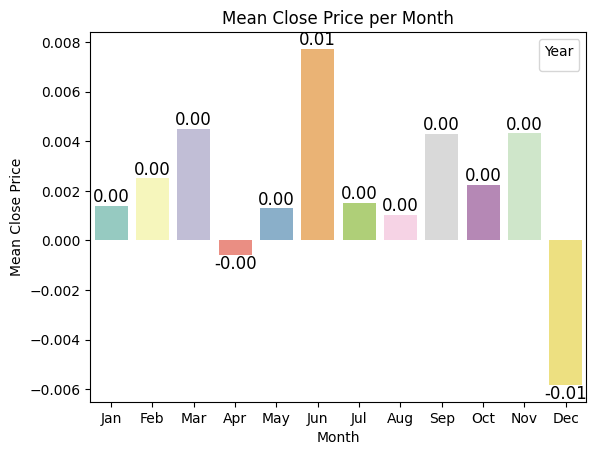

In [18]:
# Plot the mean close price per month using a Seaborn bar chart
ax =sns.barplot(data=monthly_mean, x='Month', y=target,  palette='Set3')

plt.title('Mean Close Price per Month')
plt.xlabel('Month')
plt.ylabel('Mean Close Price')

plt.xticks(range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Year')


for bars in ax.containers:
     ax.bar_label(bars, fontsize=12, fmt='%.2f')
plt.show()

In [19]:
yearly_mean.head()


,Year,r_rnet
0,2021,-0.000318
1,2022,0.002621
2,2023,0.003549
3,2024,0.002106


/var/folders/hy/d65_1v0j1lg5dzs13tpx14wm0000gn/T/ipykernel_39370/1279342536.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Year')


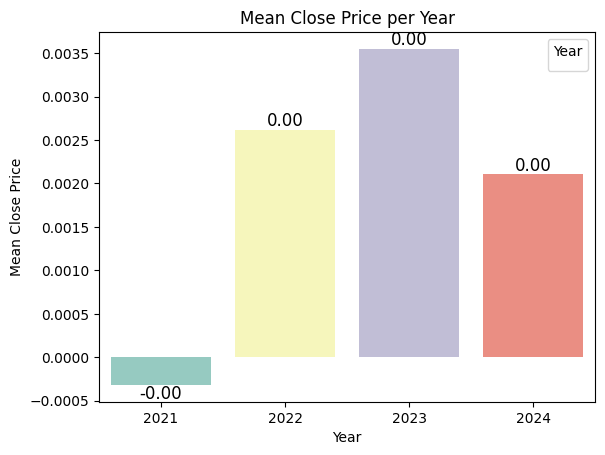

In [21]:
lst_year= yearly_mean['Year'].tolist()

# Plot the mean close price per month using a Seaborn bar chart
ax = sns.barplot(data=yearly_mean, x='Year', y=target,  palette='Set3')

plt.title('Mean Close Price per Year')
plt.xlabel('Year')
plt.ylabel('Mean Close Price')

plt.xticks(range(0, len(lst_year)), labels=lst_year)
plt.legend(title='Year')

for bars in ax.containers:
     ax.bar_label(bars, fontsize=12, fmt='%.2f')

plt.show()

/opt/anaconda3/envs/all/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/all/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/all/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/envs/all/lib/python3.12/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 l

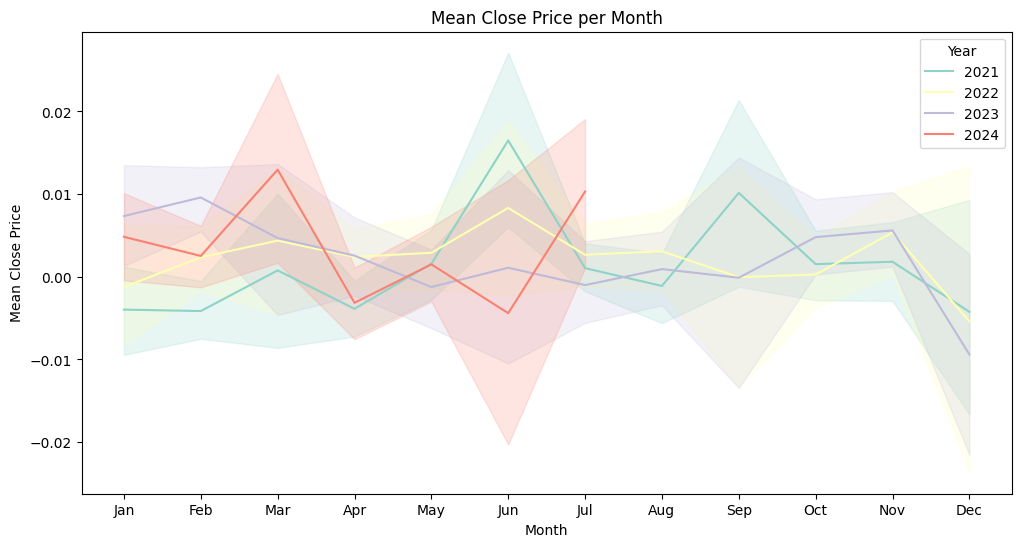

In [24]:
# Plot the mean close price per month using a Seaborn bar chart
plt.figure(figsize=(12, 6))

# filtered_df = df[df['Year'].isin([2009,2017])]
sns.lineplot(data=df, x='Month', y=target, hue='Year', palette='Set3')

plt.title('Mean Close Price per Month')

plt.xlabel('Month')
plt.ylabel('Mean Close Price')

plt.xticks(range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.legend(title='Year')
plt.show()

ValueError: The number of FixedLocator locations (48), usually from a call to set_ticks, does not match the number of labels (3).

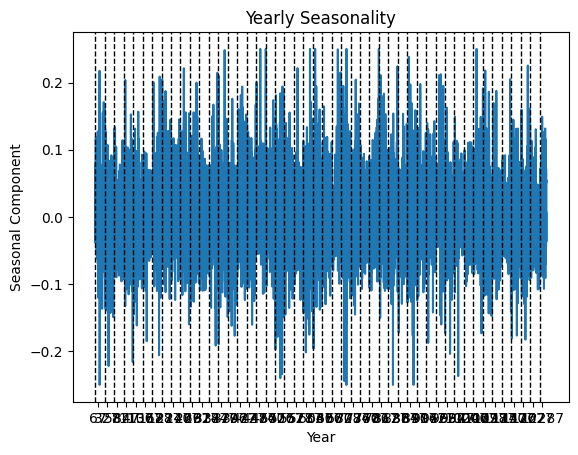

In [26]:
fig, ax = plt.subplots()

ax.plot(df[target])
for i in np.arange(0, len(df), 260):
    ax.axvline(x=i, linestyle='--', color='black', linewidth=1)

plt.title('Yearly Seasonality')
plt.xlabel('Year')
plt.ylabel('Seasonal Component')

plt.xticks(np.arange(67, len(df), 260), np.arange(2021, 2024, 1))

plt.figure(figsize=(10, 5))

fig.autofmt_xdate()
plt.tight_layout()

In [28]:
import statsmodels.api as sm

df_seasonality = df.copy()

# Set 'Date' column as the index of the DataFrame
df_seasonality.set_index('Date', inplace=True)

# Resample the data to monthly frequency
monthly_data = df_seasonality['Close'].resample('M').mean()

# Get the month numbers for the xticks
month_numbers = pd.to_datetime(monthly_data.index).strftime('%m')

df_monthly_data= monthly_data.to_frame(name="Close")
df_monthly_data['month_numbers'] = month_numbers

# Perform seasonal decomposition
decomposition = sm.tsa.seasonal_decompose(monthly_data, model='additive')

# Plot the seasonal component
fig, ax = plt.subplots()

decomposition.seasonal.plot(ax=ax)

times = np.arange('2006-01', '2023-01', dtype='datetime64[M]')
ax.set_xticks(times)
# ax.set_xticklabels(times )

for i in np.arange(0, len(df), 1):
    ax.axvline(x=i, linestyle='--', color='black', linewidth=1)

plt.title('Monthly Seasonality' ,  fontsize = 12)
plt.xlabel('Month',  fontsize = 10)
plt.ylabel('Seasonal Component',fontsize = 10)

plt.rcParams['figure.figsize'] = (30, 10)

fig.autofmt_xdate()
ax.set_xticklabels(times,rotation = 75,
                   ha = 'right', fontsize = 12,
                   color = 'blue')

plt.tight_layout()
plt.show()

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject